In [1]:
import os
import random
import shutil
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

2026-03-15 07:04:55.081314: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773558295.104121    2406 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773558295.110894    2406 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773558295.129201    2406 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773558295.129224    2406 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773558295.129227    2406 computation_placer.cc:177] computation placer alr

In [2]:

SOURCE = "/kaggle/input/datasets/odins0n/ucf-crime-dataset/Train"

DEST = "/kaggle/working/ragging_dataset"

os.makedirs(DEST + "/Ragging", exist_ok=True)
os.makedirs(DEST + "/Normal", exist_ok=True)

In [3]:
import shutil
import os 
DEST = "/kaggle/working/ragging_dataset"

if os.path.exists(DEST):
    shutil.rmtree(DEST)

os.makedirs(DEST + "/Ragging")
os.makedirs(DEST + "/Normal")

print("Dataset Folder Reset")

Dataset Folder Reset


In [4]:

ragging_classes = [
    "Assault",
    "Fighting",
    "Robbery",
    "Explosion",
    "Shooting",
    "Arrest"
]

In [5]:
TARGET = 10000

ragging_count = 0
normal_count = 0

folders = os.listdir(SOURCE)

print("Building dataset...")

for folder in tqdm(folders):

    folder_path = os.path.join(SOURCE, folder)

    if not os.path.isdir(folder_path):
        continue

    images = os.listdir(folder_path)
    random.shuffle(images)

    if folder in ragging_classes:

        for img in images:

            if ragging_count >= TARGET:
                break

            shutil.copy(
                os.path.join(folder_path, img),
                os.path.join(DEST + "/Ragging", folder + "_" + img)
            )

            ragging_count += 1

    else:

        for img in images:

            if normal_count >= TARGET:
                break

            shutil.copy(
                os.path.join(folder_path, img),
                os.path.join(DEST + "/Normal", folder + "_" + img)
            )

            normal_count += 1

    if ragging_count >= TARGET and normal_count >= TARGET:
        break

print("Ragging images:", ragging_count)
print("Normal images:", normal_count)

Building dataset...


  7%|▋         | 1/14 [00:49<10:42, 49.45s/it]

Ragging images: 10000
Normal images: 10000


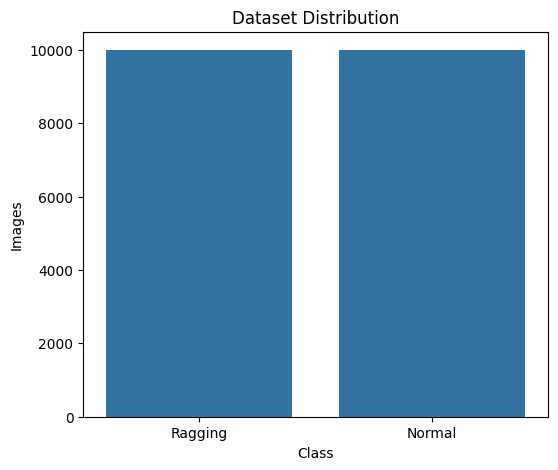

In [6]:
ragging_count = len(os.listdir(DEST + "/Ragging"))
normal_count = len(os.listdir(DEST + "/Normal"))

labels = ["Ragging", "Normal"]
counts = [ragging_count, normal_count]

plt.figure(figsize=(6,5))
sns.barplot(x=labels, y=counts)

plt.title("Dataset Distribution")
plt.ylabel("Images")
plt.xlabel("Class")

plt.show()

In [7]:
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DEST,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DEST,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(class_names)

Found 20000 files belonging to 2 classes.
Using 16000 files for training.


I0000 00:00:1773558356.436757    2406 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773558356.441848    2406 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 20000 files belonging to 2 classes.
Using 4000 files for validation.
['Normal', 'Ragging']


In [9]:

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(2000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [10]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

In [11]:
labels = []

for _, y in train_ds.unbatch():
    labels.append(int(y.numpy()))

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.9945300845350572), 1: np.float64(1.0055304172951232)}


In [12]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

In [13]:
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dense(512, activation="relu")(x)

x = tf.keras.layers.Dropout(0.5)(x)

x = tf.keras.layers.Dense(256, activation="relu")(x)

x = tf.keras.layers.Dropout(0.4)(x)

outputs = tf.keras.layers.Dense(2, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,842,405 (18.47 MB)

 Trainable params: 790,274 (3.01 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [15]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_model.h5",
        monitor="val_accuracy",
        save_best_only=True
    )

]

In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/12


E0000 00:00:1773558387.317839    2406 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1773558394.932531    2471 cuda_dnn.cc:529] Loaded cuDNN version 91002


500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6925 - loss: 0.6868

500/500 ━━━━━━━━━━━━━━━━━━━━ 66s 94ms/step - accuracy: 0.6927 - loss: 0.6865 - val_accuracy: 0.9398 - val_loss: 0.1862 - learning_rate: 1.0000e-04
Epoch 2/12
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8842 - loss: 0.2829

500/500 ━━━━━━━━━━━━━━━━━━━━ 50s 90ms/step - accuracy: 0.8842 - loss: 0.2829 - val_accuracy: 0.9660 - val_loss: 0.1099 - learning_rate: 1.0000e-04
Epoch 3/12
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9271 - loss: 0.1892

...

500/500 ━━━━━━━━━━━━━━━━━━━━ 50s 90ms/step - accuracy: 0.9642 - loss: 0.0948 - val_accuracy: 0.9883 - val_loss: 0.0404 - learning_rate: 1.0000e-04
Epoch 7/12
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9663 - loss: 0.0883

500/500 ━━━━━━━━━━━━━━━━━━━━ 50s 90ms/step - accuracy: 0.9663 - loss: 0.0883 - val_accuracy: 0.9885 - val_loss: 0.0372 - learning_rate: 1.0000e-04
Epoch 8/12
500/500 ━━━━━━━━━━━━━━━━━━━━ 50s 89ms/step - accuracy: 0.9746 - loss: 0.0708 - val_accuracy: 0.9865 - val_loss: 0.0386 - learning_rate: 1.0000e-04
Epoch 9/12
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9740 - loss: 0.0688

500/500 ━━━━━━━━━━━━━━━━━━━━ 50s 89ms/step - accuracy: 0.9740 - loss: 0.0688 - val_accuracy: 0.9887 - val_loss: 0.0322 - learning_rate: 1.0000e-04
Epoch 10/12
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9793 - loss: 0.0567

500/500 ━━━━━━━━━━━━━━━━━━━━ 50s 90ms/step - accuracy: 0.9793 - loss: 0.0567 - val_accuracy: 0.9920 - val_loss: 0.0253 - learning_rate: 1.0000e-04
Epoch 11/12
500/500 ━━━━━━━━━━━━━━━━━━━━ 50s 89ms/step - accuracy: 0.9819 - loss: 0.0536 - val_accuracy: 0.9912 - val_loss: 0.0225 - learning_rate: 1.0000e-04
Epoch 12/12
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9828 - loss: 0.0493

500/500 ━━━━━━━━━━━━━━━━━━━━ 50s 90ms/step - accuracy: 0.9828 - loss: 0.0493 - val_accuracy: 0.9927 - val_loss: 0.0218 - learning_rate: 1.0000e-04


In [17]:
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    class_weight=class_weights
)

Epoch 1/8


E0000 00:00:1773559009.934827    2406 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


500/500 ━━━━━━━━━━━━━━━━━━━━ 76s 111ms/step - accuracy: 0.9264 - loss: 0.2065 - val_accuracy: 0.9678 - val_loss: 0.0853
Epoch 2/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 58s 105ms/step - accuracy: 0.9526 - loss: 0.1321 - val_accuracy: 0.9797 - val_loss: 0.0585
Epoch 3/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 58s 105ms/step - accuracy: 0.9626 - loss: 0.1007 - val_accuracy: 0.9840 - val_loss: 0.0478
Epoch 4/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 58s 105ms/step - accuracy: 0.9687 - loss: 0.0805 - val_accuracy: 0.9865 - val_loss: 0.0398
Epoch 5/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 58s 105ms/step - accuracy: 0.9730 - loss: 0.0681 - val_accuracy: 0.9880 - val_loss: 0.0337
Epoch 6/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 58s 105ms/step - accuracy: 0.9764 - loss: 0.0619 - val_accuracy: 0.9908 - val_loss: 0.0297
Epoch 7/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 58s 105ms/step - accuracy: 0.9803 - loss: 0.0557 - val_accuracy: 0.9915 - val_loss: 0.0249
Epoch 8/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 58s 105ms/step - accuracy: 0.9822 - loss: 0.0500 - val_accura

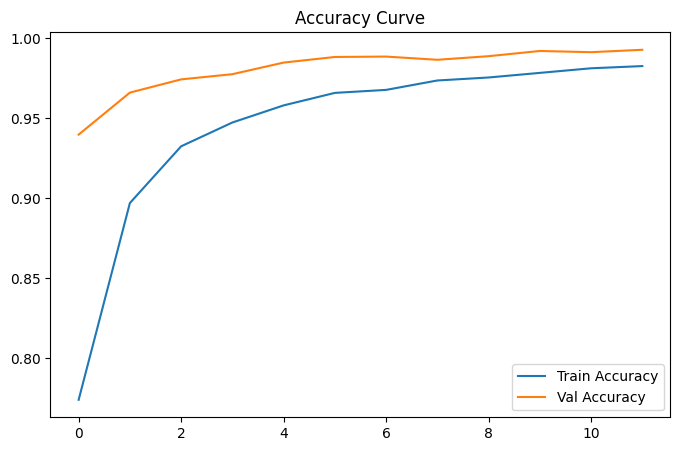

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")

plt.legend()
plt.title("Accuracy Curve")

plt.show()

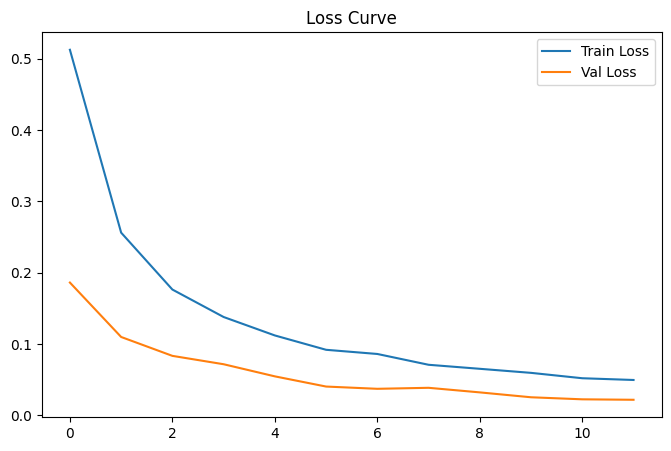

In [19]:

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")

plt.legend()
plt.title("Loss Curve")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

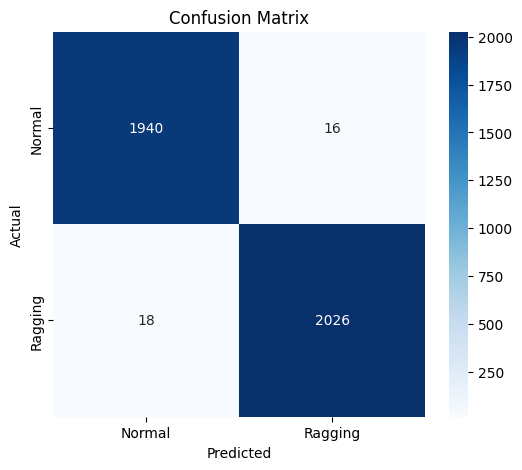

In [20]:
y_true = []
y_pred = []

for images, labels in val_ds:

    preds = model.predict(images)

    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")

plt.ylabel("Actual")
plt.xlabel("Predicted")

plt.show()


In [26]:
!wget "https://c.ndtvimg.com/2025-11/afg294jg_bengaluru-_625x300_08_November_25.jpg?im=FeatureCrop,algorithm=dnn,width=1200,height=738" -O test2.jpg

--2026-03-15 07:44:09--  https://c.ndtvimg.com/2025-11/afg294jg_bengaluru-_625x300_08_November_25.jpg?im=FeatureCrop,algorithm=dnn,width=1200,height=738
Resolving c.ndtvimg.com (c.ndtvimg.com)... 23.217.77.166, 2600:1407:7400:b8a::24e8, 2600:1407:7400:b93::24e8
Connecting to c.ndtvimg.com (c.ndtvimg.com)|23.217.77.166|:443... connected.
HTTP request sent, awaiting response... 403 Forbidden
2026-03-15 07:44:09 ERROR 403: Forbidden.



In [27]:
os.listdir()

['best_model.h5',
 '.virtual_documents',
 'test2.jpg',
 'violence_dataset',
 'ragging_dataset',
 'test.jpg']

In [29]:
from PIL import Image
image = Image.open("test2.jpg")
image.show()

UnidentifiedImageError: cannot identify image file 'test2.jpg'

In [31]:
!file test2.jpg

test2.jpg: empty


In [36]:
import requests

# Direct image URL (use the 'raw' image, not thumbnail URL if possible)
url = "https://upload.wikimedia.org/wikipedia/commons/e/e2/Street_Fight,_Jimma,_Ethiopia_(14949166234).jpg"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
}

response = requests.get(url, headers=headers, allow_redirects=True)
if response.status_code == 200:
    with open("test3.jpg", "wb") as f:
        f.write(response.content)
    print("Image downloaded successfully!")
else:
    print("Failed to download image:", response.status_code)

Image downloaded successfully!


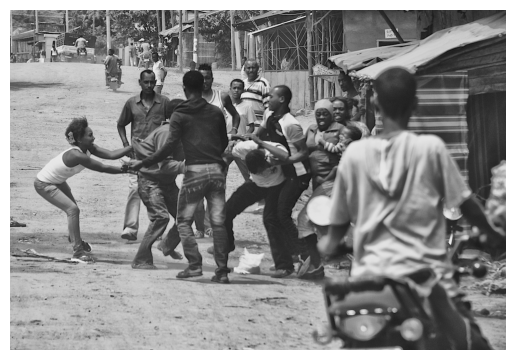

In [38]:
from PIL import Image
import matplotlib.pyplot as plt

# Load the image
image = Image.open("test2.jpg")

# Display in the notebook
plt.imshow(image)
plt.axis('off')  # hide axes
plt.show()

In [42]:
model.save("/kaggle/working/ragging_detection_model.h5")
print("Model saved")


Model saved


In [44]:
import os
os.listdir("/kaggle/working/")

['test3.jpg',
 'best_model.h5',
 '.virtual_documents',
 'test2.jpg',
 'violence_dataset',
 'ragging_dataset',
 'ragging_detection_model.h5',
 'test.jpg']